# STEP 1: DATA LOADING

## 1. Import Library

In [33]:
import pandas as pd

## 2. Load Dataset

In [34]:
file_path = "../data/raw/mobile_sales.xlsx"

df = pd.read_excel(file_path)

## 3. Preview Data

In [35]:
df.head()

,Transaction ID,Day,Month,Year,Day Name,Brand,Units Sold,Price Per Unit,Customer Name,Customer Age,City,Payment Method,Customer Ratings,Mobile Model
0,1,9,10,2021,Sat,Xiaomi,6,10174.70,Lalita Ahuja,38,Ludhiana,UPI,5,Redmi Note 10
1,2,9,10,2021,Saturday,Vivo,6,10565.19,Sneha Sharma,37,Delhi,Credit Card,3,Vivo Y51
2,3,9,10,2021,Saturday,Vivo,8,58527.58,Radha Srivastava,40,Mumbai,UPI,5,Vivo S1
3,4,10,10,2021,Sunday,Xiaomi,5,25563.98,Bhavana Arora,21,Mumbai,Credit Card,4,Mi 11
4,5,10,10,2021,Sunday,OnePlus,3,48168.02,Sneha Mehta,38,Gorakhpur,Cash,5,OnePlus 9


## 4. Check Shape

In [36]:
df.shape

(3835, 14)

## 5. Check Column Names

In [37]:
df.columns

Index(['Transaction ID', 'Day', 'Month', 'Year', 'Day Name', 'Brand',
       'Units Sold', 'Price Per Unit', 'Customer Name', 'Customer Age', 'City',
       'Payment Method', 'Customer Ratings', 'Mobile Model'],
      dtype='str')

## 6. Check Data Types

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3835 entries, 0 to 3834
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    3835 non-null   int64  
 1   Day               3835 non-null   int64  
 2   Month             3835 non-null   int64  
 3   Year              3835 non-null   int64  
 4   Day Name          3835 non-null   str    
 5   Brand             3835 non-null   str    
 6   Units Sold        3835 non-null   int64  
 7   Price Per Unit    3835 non-null   float64
 8   Customer Name     3835 non-null   str    
 9   Customer Age      3835 non-null   int64  
 10  City              3835 non-null   str    
 11  Payment Method    3835 non-null   str    
 12  Customer Ratings  3835 non-null   int64  
 13  Mobile Model      3835 non-null   str    
dtypes: float64(1), int64(7), str(6)
memory usage: 419.6 KB


## 7. Summary Statistics

In [39]:
df.describe()

,Transaction ID,Day,Month,Year,Units Sold,Price Per Unit,Customer Age,Customer Ratings
count,3835.000000,3835.000000,3835.000000,3835.000000,3835.000000,3835.000000,3835.000000,3835.000000
mean,1918.000000,15.703781,6.527249,2022.765319,4.993481,40114.036816,38.098305,3.693090
std,1107.213469,8.822771,3.452030,0.917401,2.581122,17310.488427,12.110622,1.325069
min,1.000000,1.000000,1.000000,2021.000000,1.000000,10011.110000,18.000000,1.000000
25%,959.500000,8.000000,4.000000,2022.000000,3.000000,25617.405000,27.500000,3.000000
50%,1918.000000,16.000000,7.000000,2023.000000,5.000000,40136.490000,38.000000,4.000000
75%,2876.500000,23.000000,10.000000,2024.000000,7.000000,54973.475000,49.000000,5.000000
max,3835.000000,31.000000,12.000000,2024.000000,9.000000,69984.480000,59.000000,5.000000


## 8. Clean Column Names

In [43]:
df.columns = df.columns.str.strip()

df.rename(columns={
    "Transaction ID": "Transaction_ID",
    "Day Name": "Day_Name",
    "Units Sold": "Units_Sold",
    "Price Per Unit": "Price_Per_Unit",
    "Customer Name": "Customer_Name",
    "Customer Age": "Customer_Age",
    "Payment Method": "Payment_Method",
    "Customer Ratings": "Customer_Rating",
    "Mobile Model": "Mobile_Model"
}, inplace=True)

df.columns

Index(['Transaction_ID', 'Day', 'Month', 'Year', 'Day_Name', 'Brand',
       'Units_Sold', 'Price_Per_Unit', 'Customer_Name', 'Customer_Age', 'City',
       'Payment_Method', 'Customer_Rating', 'Mobile_Model'],
      dtype='str')

## 9. Check Missing Values

In [44]:
df.isnull().sum()

Transaction_ID     0
Day                0
Month              0
Year               0
Day_Name           0
Brand              0
Units_Sold         0
Price_Per_Unit     0
Customer_Name      0
Customer_Age       0
City               0
Payment_Method     0
Customer_Rating    0
Mobile_Model       0
dtype: int64

## 10. Quick Value Check

In [45]:
df['Brand'].unique()
df['Payment_Method'].unique()

<StringArray>
['UPI', 'Credit Card', 'Cash', 'Debit Card']
Length: 4, dtype: str

# STEP 2: DATA CLEANING

## 1. Check Missing Values

In [46]:
df.isnull().sum()

Transaction_ID     0
Day                0
Month              0
Year               0
Day_Name           0
Brand              0
Units_Sold         0
Price_Per_Unit     0
Customer_Name      0
Customer_Age       0
City               0
Payment_Method     0
Customer_Rating    0
Mobile_Model       0
dtype: int64

## 2. Handle Missing Values

In [47]:
df = df.dropna()

## 3. Check Data Types

In [48]:
df.dtypes

Transaction_ID       int64
Day                  int64
Month                int64
Year                 int64
Day_Name               str
Brand                  str
Units_Sold           int64
Price_Per_Unit     float64
Customer_Name          str
Customer_Age         int64
City                   str
Payment_Method         str
Customer_Rating      int64
Mobile_Model           str
dtype: object

## 4. Fix Data Types

In [49]:
df['Customer_Age'] = df['Customer_Age'].astype(int)
df['Units_Sold'] = df['Units_Sold'].astype(int)
df['Price_Per_Unit'] = df['Price_Per_Unit'].astype(float)

## 5. Create New Column: DATE

Combine Day + Month + Year

In [50]:
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

## 6. Create Revenue Column

In [55]:
df['Revenue'] = df['Units_Sold'] * df['Price_Per_Unit']

## 7. Remove Duplicate Records

In [56]:
df = df.drop_duplicates()

## 8. Final Check

In [57]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 3835 entries, 0 to 3834
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Transaction_ID   3835 non-null   int64         
 1   Day              3835 non-null   int64         
 2   Month            3835 non-null   int64         
 3   Year             3835 non-null   int64         
 4   Day_Name         3835 non-null   str           
 5   Brand            3835 non-null   str           
 6   Units_Sold       3835 non-null   int64         
 7   Price_Per_Unit   3835 non-null   float64       
 8   Customer_Name    3835 non-null   str           
 9   Customer_Age     3835 non-null   int64         
 10  City             3835 non-null   str           
 11  Payment_Method   3835 non-null   str           
 12  Customer_Rating  3835 non-null   int64         
 13  Mobile_Model     3835 non-null   str           
 14  Date             3835 non-null   datetime64[us]
 15

,Transaction_ID,Day,Month,Year,Day_Name,Brand,Units_Sold,Price_Per_Unit,Customer_Name,Customer_Age,City,Payment_Method,Customer_Rating,Mobile_Model,Date,Revenue
0,1,9,10,2021,Sat,Xiaomi,6,10174.70,Lalita Ahuja,38,Ludhiana,UPI,5,Redmi Note 10,2021-10-09,61048.20
1,2,9,10,2021,Saturday,Vivo,6,10565.19,Sneha Sharma,37,Delhi,Credit Card,3,Vivo Y51,2021-10-09,63391.14
2,3,9,10,2021,Saturday,Vivo,8,58527.58,Radha Srivastava,40,Mumbai,UPI,5,Vivo S1,2021-10-09,468220.64
3,4,10,10,2021,Sunday,Xiaomi,5,25563.98,Bhavana Arora,21,Mumbai,Credit Card,4,Mi 11,2021-10-10,127819.90
4,5,10,10,2021,Sunday,OnePlus,3,48168.02,Sneha Mehta,38,Gorakhpur,Cash,5,OnePlus 9,2021-10-10,144504.06


# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)


## Import Libraries

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Brand-wise Sales Analysis

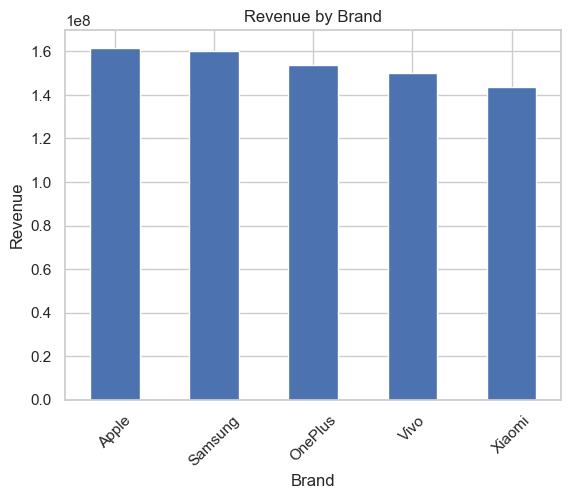

In [59]:
brand_sales = df.groupby('Brand')['Revenue'].sum().sort_values(ascending=False)

plt.figure()
brand_sales.plot(kind='bar')
plt.title("Revenue by Brand")
plt.xlabel("Brand")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Insight You’ll Get:
Which brand is top-selling
Market dominance

## 2. Monthly Sales Trend

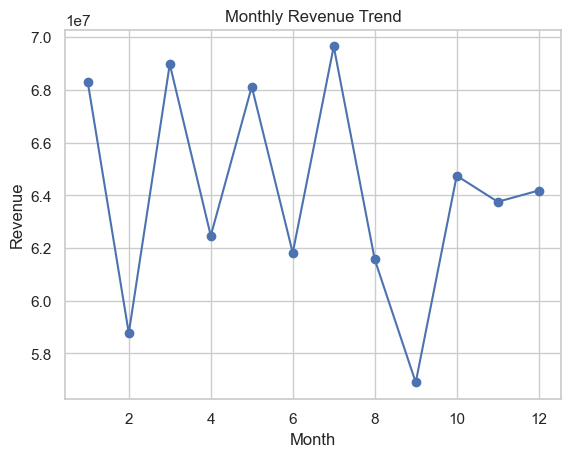

In [60]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

plt.figure()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Insight:
Peak sales months
Seasonal trends

## 3. City-wise Sales

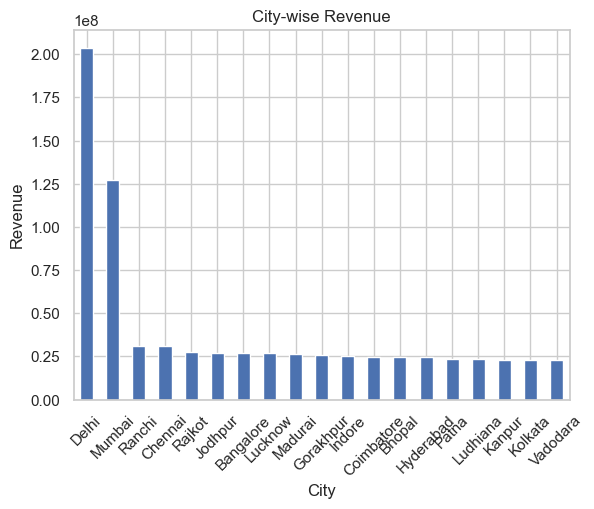

In [61]:
city_sales = df.groupby('City')['Revenue'].sum().sort_values(ascending=False)

plt.figure()
city_sales.plot(kind='bar')
plt.title("City-wise Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Insight:
Top performing cities
Target market areas

## 4. Payment Method Analysis

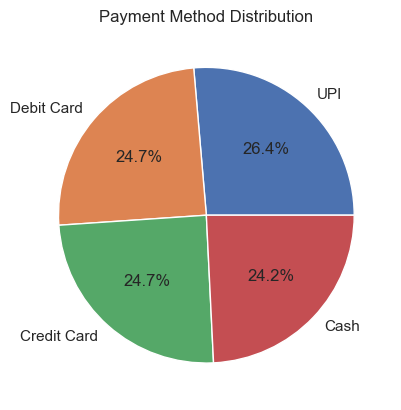

In [62]:
payment_counts = df['Payment_Method'].value_counts()

plt.figure()
payment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel('')
plt.show()

Insight:
UPI vs Cash vs Card
Customer preference

## 5. Customer Rating Analysis

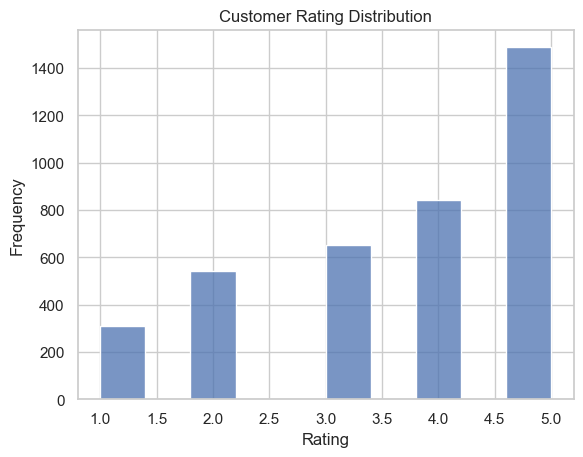

In [63]:
plt.figure()
sns.histplot(df['Customer_Rating'], bins=10)
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Insight:
Customer satisfaction
Product quality trends

## 6. Age Group vs Revenue

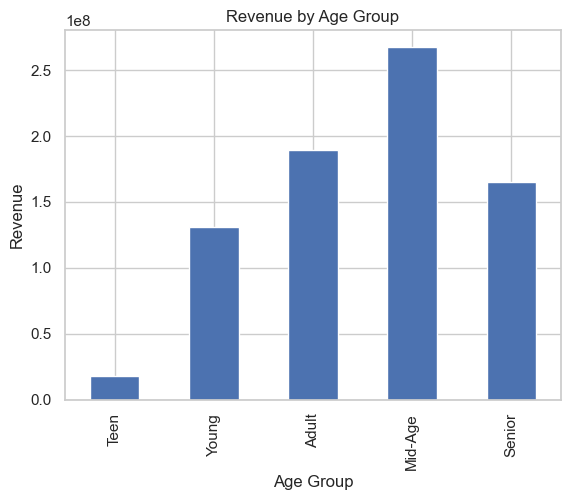

In [64]:
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=[0,18,25,35,50,100],
                         labels=['Teen','Young','Adult','Mid-Age','Senior'])

age_sales = df.groupby('Age_Group')['Revenue'].sum()

age_sales.plot(kind='bar')
plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.show()

Insight:

 Which age group buys the most

## 7. Mobile Model Performance

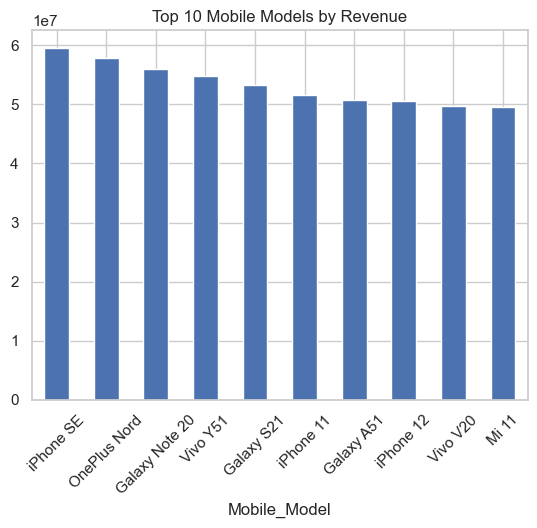

In [65]:
model_sales = df.groupby('Mobile_Model')['Revenue'].sum().sort_values(ascending=False).head(10)

model_sales.plot(kind='bar')
plt.title("Top 10 Mobile Models by Revenue")
plt.xticks(rotation=45)
plt.show()

Insight:

Best-selling models → helps in inventory decisions

## 8. Rating vs Revenue

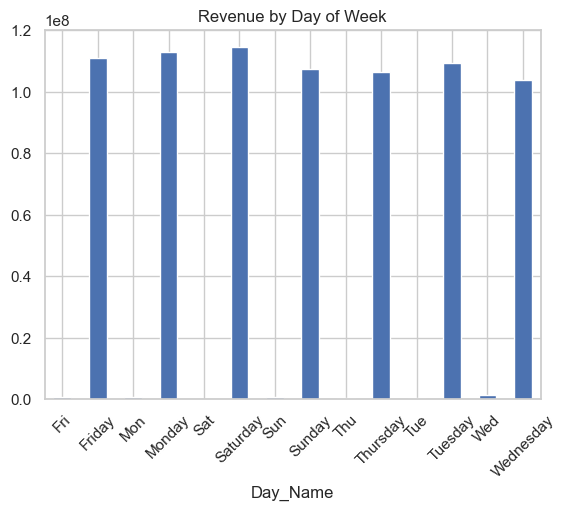

In [66]:
day_sales = df.groupby('Day_Name')['Revenue'].sum()

day_sales.plot(kind='bar')
plt.title("Revenue by Day of Week")
plt.xticks(rotation=45)
plt.show()

Insight:
Check if better ratings → more sales

## 9. Day-wise Sales Analysis

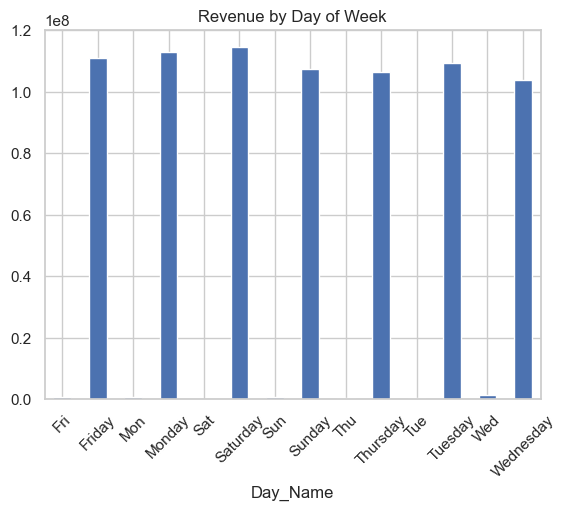

In [67]:
day_sales = df.groupby('Day_Name')['Revenue'].sum()

day_sales.plot(kind='bar')
plt.title("Revenue by Day of Week")
plt.xticks(rotation=45)
plt.show()

Insight:

Identify best sales days (weekend vs weekday)

## 5. Average Revenue per Transaction (City-wise)


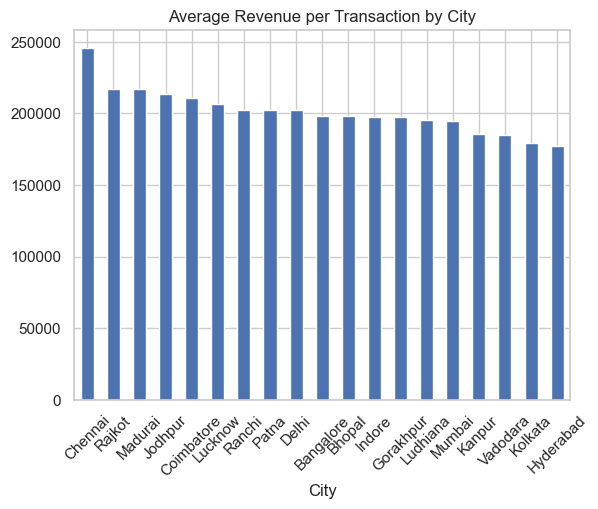

In [68]:
avg_city = df.groupby('City')['Revenue'].mean().sort_values(ascending=False)

avg_city.plot(kind='bar')
plt.title("Average Revenue per Transaction by City")
plt.xticks(rotation=45)
plt.show()

Insight:

Not just total sales — but customer spending behavior

# STEP 4: CONCLUSION

# ✅ Conclusion

This project analyzed mobile sales data to understand key patterns in customer behavior, product performance, and overall sales trends.

The analysis showed that certain brands and mobile models contribute significantly to total revenue, indicating strong customer preference. Sales trends revealed seasonal patterns, with specific months and days generating higher revenue. Additionally, metro cities were found to dominate sales, while digital payment methods like UPI and cards were more commonly used by customers.

Customer insights highlighted that particular age groups are more active buyers, and higher customer ratings are often associated with better sales performance. Variations in average transaction values across cities also indicate differences in customer spending behavior.

Overall, this analysis demonstrates how data can be used to identify trends, optimize business strategies, and support better decision-making. By leveraging these insights, businesses can improve sales performance, target the right customers, and enhance overall customer satisfaction.

# STEP 5: DECISIONS BASED ON PROJECT INSIGHTS

# 💼 Business Decisions Based on Insights

Based on the analysis of mobile sales data, the following strategic decisions can be made:

### 📦 Inventory Management
- Increase stock for top-performing brands and mobile models to meet high demand
- Reduce inventory for low-performing products to avoid overstocking

### 📈 Marketing Strategy
- Focus marketing campaigns during peak sales months to maximize revenue
- Run promotional offers and discounts during low-sales periods to boost demand

### 📍 Regional Strategy
- Allocate more resources and marketing efforts in high-performing cities
- Explore growth opportunities in underperforming cities

### 💳 Payment Strategy
- Promote digital payment methods (UPI, cards) through cashback and offers
- Optimize checkout experience for commonly used payment methods

### 👥 Customer Targeting
- Target high-contributing age groups with personalized marketing campaigns
- Design offers tailored to customer preferences and buying behavior

### ⭐ Product Improvement
- Improve quality and service for products with lower customer ratings
- Focus on maintaining high standards for top-rated products

### 📅 Sales Optimization
- Launch special offers and campaigns on high-performing days (e.g., weekends)
- Plan sales events based on customer buying patterns

### 💰 Revenue Growth Strategy
- Focus on cities with high average transaction value to maximize profitability
- Introduce premium product offerings in high-spending regions

# Thank You...😊